# 17.3.2 伴随精度与模型消融

## 学习目标与先修知识

改变数值步长及非线性项，识别训练改善和独立外推的边界。

先修：17.2.2 连续伴随与机制基线。

## 具体问题

更细的求解网格和更多向量场（vector field）参数（parameter），总能改善独立初态的预测吗？

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
for h in [.1,.05,.025]:print(h,"观测点数",int(2/h)+1)

0.1 观测点数 21
0.05 观测点数 41
0.025 观测点数 81


## 模型假设

固定同一解析生成轨迹（trajectory）、初态和观测（observation）时刻；粗细网格仅改变数值离散。机制基线 c=d=0；增广 tanh 项只增加自由度（degrees of freedom），不提前读取独立初态测试值。两组实验分别考察求解精度与模型结构（model structure）。后面的配对统计把“失败”限定为有数值预测但未通过预设质量检查；对应误差仍有定义。

## 数学解释与推导

连续伴随梯度（gradient）与中心差分（central difference）的一致性随 $h$ 细化可作数值检查，但误差下降不保证优化找到更好的参数。若真实生成过程就是线性螺旋，加入 $\tanh$ 项的训练损失可能下降，却没有理由自动改善新初态或外推。消融必须一次只变一个因素，报告失败项。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def spiral_rhs(state, parameters):
    """Four-parameter tanh vector field; linear damped spiral when c=d=0."""
    x,y=np.asarray(state,dtype=float);a,omega,c,d=parameters
    return np.array([-a*x-omega*y+c*np.tanh(x),omega*x-a*y+d*np.tanh(y)])


def spiral_state_jacobian(state, parameters):
    x,y=np.asarray(state,dtype=float);a,omega,c,d=parameters
    return np.array([[-a+c*(1-np.tanh(x)**2),-omega],
                     [omega,-a+d*(1-np.tanh(y)**2)]])


def spiral_parameter_jacobian(state, parameters):
    x,y=np.asarray(state,dtype=float)
    return np.array([[-x,-y,np.tanh(x),0.],[-y,x,0.,np.tanh(y)]])


def spiral_exact(initial,a,omega,times):
    initial=np.asarray(initial,dtype=float);times=np.asarray(times,dtype=float)
    theta=omega*times;factor=np.exp(-a*times)
    return np.column_stack([factor*(initial[0]*np.cos(theta)-initial[1]*np.sin(theta)),
                            factor*(initial[0]*np.sin(theta)+initial[1]*np.cos(theta))])


def rk4_path(rhs, initial, h, steps):
    state=np.asarray(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        k1=np.asarray(rhs(state));k2=np.asarray(rhs(state+h*k1/2))
        k3=np.asarray(rhs(state+h*k2/2));k4=np.asarray(rhs(state+h*k3))
        state=state+h*(k1+2*k2+2*k3+k4)/6
        rows.append(state.copy())
    return np.asarray(rows)


def rk4_spiral(initial,parameters,h,steps):
    return rk4_path(lambda state:spiral_rhs(state,parameters),initial,h,steps)


def adjoint_spiral(initial,parameters,h,observed_indices,targets):
    """Continuous adjoint integrated backward on a fixed RK4 grid; observations jump lambda."""
    path=rk4_spiral(initial,parameters,h,max(observed_indices))
    indices=np.asarray(observed_indices,dtype=int)
    targets=np.asarray(targets,dtype=float)
    residual=path[indices]-targets
    loss=float(np.mean(np.sum(residual*residual,axis=1))/2)
    jump={int(index):residual[j]/len(indices) for j,index in enumerate(indices)}
    lam=np.zeros(2);gradient=np.zeros(4)
    for step in range(len(path)-1,-1,-1):
        if step in jump:lam=lam+jump[step]
        if step==0:break
        z0,z1=path[step],path[step-1];middle=(z0+z1)/2
        def derivative(vec,state):
            l=vec[:2]
            return np.r_[-spiral_state_jacobian(state,parameters).T@l,
                         -spiral_parameter_jacobian(state,parameters).T@l]
        value=np.r_[lam,gradient];dt=-h
        k1=derivative(value,z0);k2=derivative(value+dt*k1/2,middle)
        k3=derivative(value+dt*k2/2,middle);k4=derivative(value+dt*k3,z1)
        value=value+dt*(k1+2*k2+2*k3+k4)/6
        lam,gradient=value[:2],value[2:]
    return loss,gradient,path

## 对照实验

固定训练和评估条件，展示当前任务的正例或反例。

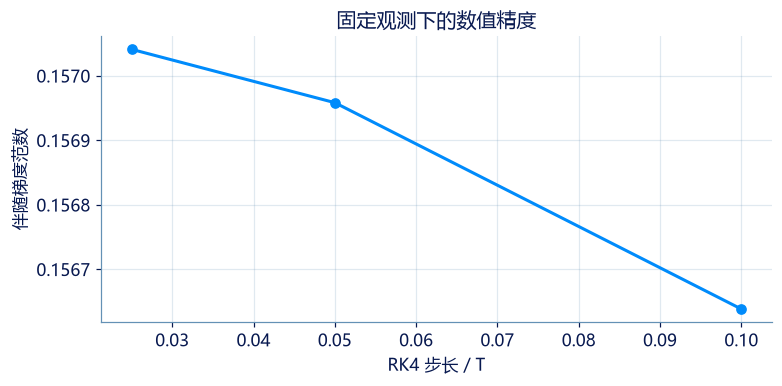

[(0.1, 0.012391621192658332, 0.1566383579823143), (0.05, 0.012388998628559774, 0.1569583182531446), (0.025, 0.01238883887036339, 0.15704103198140787)]


In [4]:
rows=[];theta=np.array([.11,1.85,.02,-.02]);target=spiral_exact([1.,0.],.08,2.,np.linspace(0,2,21))
for h in [.1,.05,.025]:
    step=int(round(.1/h));indices=np.arange(21)*step;loss,grad,_=adjoint_spiral([1.,0.],theta,h,indices,target);rows.append((h,loss,float(np.linalg.norm(grad))))
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot([row[0] for row in rows],[row[2] for row in rows],"o-",color=BLUE);ax.set(xlabel="RK4 步长 / T",ylabel="伴随梯度范数",title="固定观测下的数值精度");ax.grid(alpha=.2);plt.show();print(rows)

## 结果解释

三档梯度范数（norm）接近是数值一致性的线索，不是外推优越性或原文 Table 2 复现。模型（model）消融需另看相同独立初态测试和预算。

### 独立核对

用代数、解析解（analytical solution）或预留条件交叉检查。

In [5]:
assert all(np.isfinite(row[1:]).all() for row in rows);assert abs(rows[-1][2]-rows[-2][2])<.05
independent=spiral_exact([.7,-.3],.08,2.,np.arange(101)*.02);mechanism=rk4_spiral([.7,-.3],[.08,2.,0.,0.],.02,100);candidate=rk4_spiral([.7,-.3],theta,.02,100)
assert np.mean((independent-mechanism)**2)<np.mean((independent-candidate)**2)
print("数值一致性和该参数下的独立基线反例通过。")

数值一致性和该参数下的独立基线反例通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：精度与性能

细化积分网格后梯度（gradient）更稳定，是否等于外推误差一定下降？

- **A.** 等于，数值一致性就是泛化
- **B.** 不等于，还要在独立条件评价
- **C.** 等于，训练点更多
- **D.** 数值步长与梯度无关

[作答：精度与性能](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-c3s2-choice1)

### 第 2 题 · 单项选择题：模型自由度

真生成场是线性螺旋，增加 tanh 项后应该报告什么？

- **A.** 只报告训练误差
- **B.** 只报告最好参数（parameter）
- **C.** 训练误差和新初态外推误差都报告
- **D.** 把线性基线删除

[作答：模型自由度](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-c3s2-choice2)

### 第 3 题 · Python 计算题：独立初态解析线

更细的求解网格和更多向量场（vector field）参数（parameter），总能改善独立初态的预测吗？本题计算“独立初态解析线”：每个时刻用 exp(-a*t) 乘旋转矩阵（matrix）作用于 initial。请按下方具名参数和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    initial: list[float],
    a: float,
    omega: float,
    times: list[float],
) -> list[list[float]]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[float]` | 二维线性螺旋初态。 | 归一化状态 |
| `a` | `float` | 指数衰减率。 | 1/T |
| `omega` | `float` | 旋转角频率。 | 1/T |
| `times` | `list[float]` | 从初态开始的时间。 | T |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 每个时间对应的二维解析状态（state）。 | 归一化状态 |

**计算规则**

每个时刻用 exp(-a*t) 乘旋转矩阵作用于 initial。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 二维线性螺旋初态。 | [1.0, 0.0] | 归一化状态 |
| a | 指数衰减率。 | 0 | 1/T |
| omega | 旋转角频率。 | 0 | 1/T |
| times | 从初态开始的时间。 | [0.0, 1.0] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [1.0, 0.0]
a = 0.0
omega = 0.0
times = [0.0, 1.0]

result = solve(initial, a, omega, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 每个时间对应的二维解析状态（state）。 | [[1.0, 0.0], [1.0, 0.0]] | 归一化状态 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[1.0, 0.0], [1.0, 0.0]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；每个时刻用 exp(-a*t) 乘旋转矩阵作用于 initial。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：独立初态解析线](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-independent-spiral)

### 第 4 题 · Python 计算题：保留失败的配对统计

更细的求解网格和更多向量场（vector field）参数（parameter），总能改善独立初态的预测吗？本题计算“保留失败的配对统计”：配对差 d=baseline-method；标准误（standard error）为样本标准差（standard deviation）/sqrt(n)，n=1 时规定为0；失败表示候选仍有数值预测，但未通过质量检查；对应误差继续参与配对统计，失败率使用全部场景。请按下方具名参数和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    baseline: list[float],
    method: list[float],
    failures: list[bool],
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `baseline` | `list[float]` | 全部场景的基线误差。 | U |
| `method` | `list[float]` | 同序候选数值预测的误差；质量检查失败时仍有定义。 | U |
| `failures` | `list[bool]` | 候选有数值预测，但未通过预设质量检查（如收支（mass balance）或非负性（nonnegativity））的标志。 | 1 |

**返回值**

直接返回 report（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `report` | `list[float]` | 基线减候选的均值、样本标准误和失败率。 | 混合 |

**计算规则**

每组都有定义明确的基线和候选误差；failures=True 仅表示候选数值预测未通过预设质量检查。全部场景均进入 d=baseline-method 的均值和标准误计算；标准误为样本标准差/sqrt(n)，n=1 时取 0。失败率为 True 数量/全部场景数。无有效数值输出（output）的求解失败不属于本接口；此时应另报双方成功场景的配对统计和全体失败率。

**约束与边界**

- 三个列表等长且至少一组；全部误差有限，列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| baseline | 全部场景的基线误差。 | [0.3, 0.4] | U |
| method | 同序候选数值预测的误差；质量检查失败时仍有定义。 | [0.2, 0.5] | U |
| failures | 候选有数值预测，但未通过预设质量检查（如收支（mass balance）或非负性（nonnegativity））的标志。 | [False, True] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
baseline = [0.3, 0.4]
method = [0.2, 0.5]
failures = [False, True]

result = solve(baseline, method, failures)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| report | 基线减候选的均值、样本标准误和失败率。 | [0.0, 0.09999999999999998, 0.5] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.09999999999999998, 0.5]
```

**样例解释**

第二组虽标记质量检查失败，候选误差 0.5 U 仍有定义。两组配对差为 0.1 与 -0.1 U，均值为 0、标准误为 0.1 U；失败率为 1/2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：保留失败的配对统计](http://127.0.0.1:8000/chapters/17-03-%E6%B6%88%E8%9E%8D%E3%80%81%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E8%AE%BA%E8%BE%B9%E7%95%8C/practice/?question=p17-paired-failure)